In [1]:
pip install imbalanced-learn

  Using cached imbalanced_learn-0.12.3-py3-none-any.whl.metadata (8.3 kB)
Using cached imbalanced_learn-0.12.3-py3-none-any.whl (258 kB)

[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install lightgbm


  Using cached lightgbm-4.5.0-py3-none-manylinux_2_28_x86_64.whl.metadata (17 kB)
Using cached lightgbm-4.5.0-py3-none-manylinux_2_28_x86_64.whl (3.6 MB)

[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# LightGBM vs Logistic regression
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# Function for loading random data
def load_random_subset(file_path, num_rows, random_seed):
    df = pd.read_csv(file_path)
    if num_rows > len(df):
        print(f"Requested {num_rows} rows, but the dataset contains only {len(df)} rows. Sampling all rows.")
        num_rows = len(df)
    return df.sample(n=num_rows, random_state=random_seed)

# Setting random seed
random_seed = 42

# Loading a random data from train_data.csv
train_data_subset = load_random_subset('train_data.csv', 200000, random_seed)
train_labels = pd.read_csv('train_labels.csv')


# Extracting customer_IDs from train_data_subset
sampled_customer_ids = train_data_subset['customer_ID']

# Filter train_labels to match the customer_IDs from the train_data_subset
train_labels_subset = train_labels[train_labels['customer_ID'].isin(sampled_customer_ids)]

# Merging train_data with train_labels
train_subset = pd.merge(train_data_subset, train_labels_subset, on='customer_ID')

# Separating features and target
X_subset = train_subset.drop(columns=['customer_ID', 'target'])
y_subset = train_subset['target']

# Loading a random data from test_data.csv
test_data_subset = load_random_subset('test_data.csv', 200000, random_seed)

# Preparing test data
X_test_subset = test_data_subset.drop(columns=['customer_ID'])
test_customer_ids = test_data_subset['customer_ID']

# separating categorical and numerical columns
categorical_cols = ['B_30', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120', 'D_126', 'D_63', 'D_64', 'D_66', 'D_68']
numerical_cols = [col for col in X_subset.columns if col not in categorical_cols]

# checking if numerical columns are numeric
for col in numerical_cols:
    X_subset[col] = pd.to_numeric(X_subset[col], errors='coerce')
    X_test_subset[col] = pd.to_numeric(X_test_subset[col], errors='coerce')

# Preprocessing pipelines for numerical and categorical data
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Apply to numerical columns
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Apply to categorical columns
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Applying SMOTE to handle class imbalance
smote = SMOTE(random_state=42)

# Defining models for comparison
models = {
    'LightGBM': lgb.LGBMClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
}

# Spliting data into training and validation sets
X_train_subset, X_val_subset, y_train_subset, y_val_subset = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42, stratify=y_subset
)

# Initializing a dictionary to store evaluation metrics
metrics = {}

# copying for plotting graph
y_true_lr_vs_lgb = y_val_subset


# Initializing variables to store predictions and probabilities
y_pred_lightgbm, y_proba_lightgbm = None, None
y_pred_logreg, y_proba_logreg = None, None


# Train and evaluate each model
for model_name, model in models.items():
    
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', smote),
        ('classifier', model)
    ])

    pipeline.fit(X_train_subset, y_train_subset)
    
    # predicting on the validation set
    y_pred_subset = pipeline.predict(X_val_subset)
    y_pred_proba_subset = pipeline.predict_proba(X_val_subset)[:, 1]
    
    # Storing predictions and probabilities by model name
    if model_name == "LightGBM":
        y_pred_lightgbm = y_pred_subset
        y_proba_lightgbm = y_pred_proba_subset
    elif model_name == "Logistic Regression":
        y_pred_logreg = y_pred_subset
        y_proba_logreg = y_pred_proba_subset    
    
    # Evaluating model
    print(f"Model: {model_name}")
    print("Classification Report:")
    print(classification_report(y_val_subset, y_pred_subset))
    
    # Calculating metrics
    roc_auc = roc_auc_score(y_val_subset, y_pred_proba_subset)
    f1 = f1_score(y_val_subset, y_pred_subset)
    print(f"ROC-AUC Score: {roc_auc}")
    print(f"F1 Score: {f1}")
    print("\n" + "="*50 + "\n")
    
    metrics[model_name] = {'roc_auc': roc_auc, 'f1_score': f1}

# Preprocessing the test data and making predictions using the best model
best_model = models['LightGBM'] 
best_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', best_model)
])
best_pipeline.fit(X_train_subset, y_train_subset)
X_test_processed = best_pipeline.named_steps['preprocessor'].transform(X_test_subset)
test_predictions = best_pipeline.named_steps['classifier'].predict(X_test_processed)

# Saving results to dataframe
predictions_df = pd.DataFrame({
    'customer_ID': test_customer_ids,
    'prediction': test_predictions
})

# Saving result into CSV
predictions_df.to_csv('LightGBMvsLogisticRegressionPredictions.csv', index=False)

print("Predictions have been saved to LightGBMvsLogisticRegressionPredictions.csv.")


/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


[LightGBM] [Info] Number of positive: 119925, number of negative: 119925
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.284475 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 55215
[LightGBM] [Info] Number of data points in the train set: 239850, number of used features: 221
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Model: LightGBM
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91     29981
           1       0.73      0.78      0.75     10019

    accuracy                           0.87     40000
   macro avg       0.83      0.84      0.83     40000
weighted avg       0.88      0.87      0.87     40000

ROC-AUC Score: 0.9340052605895836
F1 Score: 0.7524264812400406




/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Model: Logistic Regression
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.84      0.90     29981
           1       0.65      0.88      0.75     10019

    accuracy                           0.85     40000
   macro avg       0.80      0.86      0.82     40000
weighted avg       0.88      0.85      0.86     40000

ROC-AUC Score: 0.930453155648143
F1 Score: 0.7490643075876149




/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


[LightGBM] [Info] Number of positive: 119925, number of negative: 119925
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.300502 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 55215
[LightGBM] [Info] Number of data points in the train set: 239850, number of used features: 221
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Predictions have been saved to LightGBMvsLogisticRegressionPredictions.csv.


In [4]:
# LightGBM vs KNN
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import lightgbm as lgb
from sklearn.neighbors import KNeighborsClassifier

# Function for loading random data
def load_random_subset(file_path, num_rows, random_seed):
    df = pd.read_csv(file_path)
    if num_rows > len(df):
        print(f"Requested {num_rows} rows, but the dataset contains only {len(df)} rows. Sampling all rows.")
        num_rows = len(df)
    return df.sample(n=num_rows, random_state=random_seed)

# Setting random seed
random_seed = 42

# Loading a random data from train_data.csv
train_data_subset = load_random_subset('train_data.csv', 200000, random_seed)
train_labels = pd.read_csv('train_labels.csv')

# Extracting customer_IDs from train_data_subset
sampled_customer_ids = train_data_subset['customer_ID']

# Filter train_labels to match the customer_IDs from the train_data_subset
train_labels_subset = train_labels[train_labels['customer_ID'].isin(sampled_customer_ids)]

# Merging train_data with train_labels
train_subset = pd.merge(train_data_subset, train_labels_subset, on='customer_ID')

# Separating features and target
X_subset = train_subset.drop(columns=['customer_ID', 'target'])
y_subset = train_subset['target']

# Loading a random data from test_data.csv
test_data_subset = load_random_subset('test_data.csv', 200000, random_seed)

# Preparing test data
X_test_subset = test_data_subset.drop(columns=['customer_ID'])
test_customer_ids = test_data_subset['customer_ID']

# separating categorical and numerical columns
categorical_cols = ['B_30', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120', 'D_126', 'D_63', 'D_64', 'D_66', 'D_68']
numerical_cols = [col for col in X_subset.columns if col not in categorical_cols]

# checking if numerical columns are numeric
for col in numerical_cols:
    X_subset[col] = pd.to_numeric(X_subset[col], errors='coerce')
    X_test_subset[col] = pd.to_numeric(X_test_subset[col], errors='coerce')

# Preprocessing pipelines for numerical and categorical data
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Apply to numerical columns
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Apply to categorical columns
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Applying SMOTE to handle class imbalance
smote = SMOTE(random_state=42)

# Defining models for comparison
models = {
    'LightGBM': lgb.LGBMClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# Spliting data into training and validation sets
X_train_subset, X_val_subset, y_train_subset, y_val_subset = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42, stratify=y_subset
)

# Initializing a dictionary to store evaluation metrics
metrics = {}

# for plotting graph
y_true_knn_vs_lgb = y_val_subset 

# Initializing variables to store predictions and probabilities
y_pred_lightgbm, y_proba_lightgbm = None, None
y_pred_knn, y_proba_knn = None, None

# Train and evaluate each model
for model_name, model in models.items():
    # Create pipeline
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', smote),
        ('classifier', model)
    ])

    pipeline.fit(X_train_subset, y_train_subset)
    
    # predicting on the validation set
    y_pred_subset = pipeline.predict(X_val_subset)
    y_pred_proba_subset = pipeline.predict_proba(X_val_subset)[:, 1]
    
    # Storing predictions and probabilities by model names
    if model_name == 'LightGBM':
        y_pred_lightgbm = y_pred_subset
        y_proba_lightgbm = y_pred_proba_subset 
    elif model_name == 'K-Nearest Neighbors':
        y_pred_knn = y_pred_subset
        y_proba_knn = y_pred_proba_subset   
    
    # Evaluating model
    print(f"Model: {model_name}")
    print("Classification Report:")
    print(classification_report(y_val_subset, y_pred_subset))
    
    # Calculating metrics
    roc_auc = roc_auc_score(y_val_subset, y_pred_proba_subset)
    f1 = f1_score(y_val_subset, y_pred_subset)
    print(f"ROC-AUC Score: {roc_auc}")
    print(f"F1 Score: {f1}")
    print("\n" + "="*50 + "\n")
  
    metrics[model_name] = {'roc_auc': roc_auc, 'f1_score': f1}

# Preprocessing the test data and making predictions using the best model
best_model = models['LightGBM']  
best_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', best_model)
])
best_pipeline.fit(X_train_subset, y_train_subset)
X_test_processed = best_pipeline.named_steps['preprocessor'].transform(X_test_subset)
test_predictions = best_pipeline.named_steps['classifier'].predict(X_test_processed)

# Saving results to dataframe
predictions_df = pd.DataFrame({
    'customer_ID': test_customer_ids,
    'prediction': test_predictions
})

# Saving results to CSV
predictions_df.to_csv('LightGBMvsKNearestNeighborsPredictions.csv.csv', index=False)

print("Predictions have been saved to LightGBMvsKNearestNeighborsPredictions.csv.")


/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


[LightGBM] [Info] Number of positive: 119925, number of negative: 119925
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.261865 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 55215
[LightGBM] [Info] Number of data points in the train set: 239850, number of used features: 221
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Model: LightGBM
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91     29981
           1       0.73      0.78      0.75     10019

    accuracy                           0.87     40000
   macro avg       0.83      0.84      0.83     40000
weighted avg       0.88      0.87      0.87     40000

ROC-AUC Score: 0.9340052605895836
F1 Score: 0.7524264812400406




/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Model: K-Nearest Neighbors
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.82      0.89     29981
           1       0.63      0.93      0.75     10019

    accuracy                           0.84     40000
   macro avg       0.80      0.87      0.82     40000
weighted avg       0.89      0.84      0.85     40000

ROC-AUC Score: 0.9316525944689612
F1 Score: 0.7488132593128973




/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


[LightGBM] [Info] Number of positive: 119925, number of negative: 119925
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.282444 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 55215
[LightGBM] [Info] Number of data points in the train set: 239850, number of used features: 221
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Predictions have been saved to LightGBMvsKNearestNeighborsPredictions.csv.


In [5]:
# LightGBM vs Decision tree
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import lightgbm as lgb
from sklearn.tree import DecisionTreeClassifier
import joblib  # Add joblib to handle model saving

# Function for loading random data
def load_random_subset(file_path, num_rows, random_seed):
    df = pd.read_csv(file_path)
    if num_rows > len(df):
        print(f"Requested {num_rows} rows, but the dataset contains only {len(df)} rows. Sampling all rows.")
        num_rows = len(df)
    return df.sample(n=num_rows, random_state=random_seed)

# Setting random seed
random_seed = 42

# Loading a random data from train_data.csv
train_data_subset = load_random_subset('train_data.csv', 200000, random_seed)
train_labels = pd.read_csv('train_labels.csv')

# Extracting customer_IDs from train_data_subset
sampled_customer_ids = train_data_subset['customer_ID']

# Filter train_labels to match the customer_IDs from the train_data_subset
train_labels_subset = train_labels[train_labels['customer_ID'].isin(sampled_customer_ids)]

# Merging train_data with train_labels
train_subset = pd.merge(train_data_subset, train_labels_subset, on='customer_ID')

# Separating features and target
X_subset = train_subset.drop(columns=['customer_ID', 'target'])
y_subset = train_subset['target']

# Loading a random data from test_data.csv
test_data_subset = load_random_subset('test_data.csv', 200000, random_seed)

# Preparing test data
X_test_subset = test_data_subset.drop(columns=['customer_ID'])
test_customer_ids = test_data_subset['customer_ID']

# separating categorical and numerical columns
categorical_cols = ['B_30', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120', 'D_126', 'D_63', 'D_64', 'D_66', 'D_68']
numerical_cols = [col for col in X_subset.columns if col not in categorical_cols]

# checking if numerical columns are numeric
for col in numerical_cols:
    X_subset[col] = pd.to_numeric(X_subset[col], errors='coerce')
    X_test_subset[col] = pd.to_numeric(X_test_subset[col], errors='coerce')

# Preprocessing pipelines for numerical and categorical data
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Apply to numerical columns
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Apply to categorical columns
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Applying SMOTE to handle class imbalance
smote = SMOTE(random_state=42)

# Defining models for comparison
models = {
    'LightGBM': lgb.LGBMClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# Spliting data into training and validation sets
X_train_subset, X_val_subset, y_train_subset, y_val_subset = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42, stratify=y_subset
)

# Initializing a dictionary to store evaluation metrics
metrics = {}

# for plotting graph
y_true_tree_vs_lgb = y_val_subset


# Initializing variables to store predictions and probabilities
y_pred_lightgbm, y_proba_lightgbm = None, None
y_pred_tree, y_proba_tree = None, None

# Train and evaluate each model
for model_name, model in models.items():
    # Create pipeline
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', smote),
        ('classifier', model)
    ])

    pipeline.fit(X_train_subset, y_train_subset)
    
    # Saving the trained models for further use
    joblib.dump(pipeline, f'{model_name}_pipeline.pkl')
    print(f"Saved {model_name} pipeline as {model_name}_pipeline.pkl")
    
    # predicting on the validation set
    y_pred_subset = pipeline.predict(X_val_subset)
    y_pred_proba_subset = pipeline.predict_proba(X_val_subset)[:, 1]
    
    if model_name == "LightGBM":
        y_pred_lightgbm = y_pred_subset
        y_proba_lightgbm = y_pred_proba_subset
    elif model_name == "Decision Tree":
        y_pred_tree = y_pred_subset
        y_proba_tree = y_pred_proba_subset
    
    # Evaluating model
    print(f"Model: {model_name}")
    print("Classification Report:")
    print(classification_report(y_val_subset, y_pred_subset))
    
    # Calculating metrics
    roc_auc = roc_auc_score(y_val_subset, y_pred_proba_subset)
    f1 = f1_score(y_val_subset, y_pred_subset)
    print(f"ROC-AUC Score: {roc_auc}")
    print(f"F1 Score: {f1}")
    print("\n" + "="*50 + "\n")

    metrics[model_name] = {'roc_auc': roc_auc, 'f1_score': f1}

# Preprocess the test data and making predictions using the best model 
best_model = models['LightGBM']
best_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', best_model)
])
best_pipeline.fit(X_train_subset, y_train_subset)
X_test_processed = best_pipeline.named_steps['preprocessor'].transform(X_test_subset)
test_predictions = best_pipeline.named_steps['classifier'].predict(X_test_processed)

# saving results to dataframe
predictions_df = pd.DataFrame({
    'customer_ID': test_customer_ids,
    'prediction': test_predictions
})

# Saving predictions to CSV
predictions_df.to_csv('LightGBMvsDecisionTreePredictions.csv', index=False)

print("Predictions have been saved to LightGBMvsDecisionTreePredictions.csv.")


/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


[LightGBM] [Info] Number of positive: 119925, number of negative: 119925
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.266154 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 55215
[LightGBM] [Info] Number of data points in the train set: 239850, number of used features: 221
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Saved LightGBM pipeline as LightGBM_pipeline.pkl


/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Model: LightGBM
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91     29981
           1       0.73      0.78      0.75     10019

    accuracy                           0.87     40000
   macro avg       0.83      0.84      0.83     40000
weighted avg       0.88      0.87      0.87     40000

ROC-AUC Score: 0.9340052605895836
F1 Score: 0.7524264812400406




/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


...

Model: Decision Tree
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87     29981
           1       0.61      0.66      0.63     10019

    accuracy                           0.81     40000
   macro avg       0.75      0.76      0.75     40000
weighted avg       0.81      0.81      0.81     40000

ROC-AUC Score: 0.7578669122110504
F1 Score: 0.6323040608892528




/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


[LightGBM] [Info] Number of positive: 119925, number of negative: 119925
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.561336 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 55215
[LightGBM] [Info] Number of data points in the train set: 239850, number of used features: 221
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Predictions have been saved to LightGBMvsDecisionTreePredictions.csv.


/tmp/ipykernel_121/4069773848.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(cmap_name)


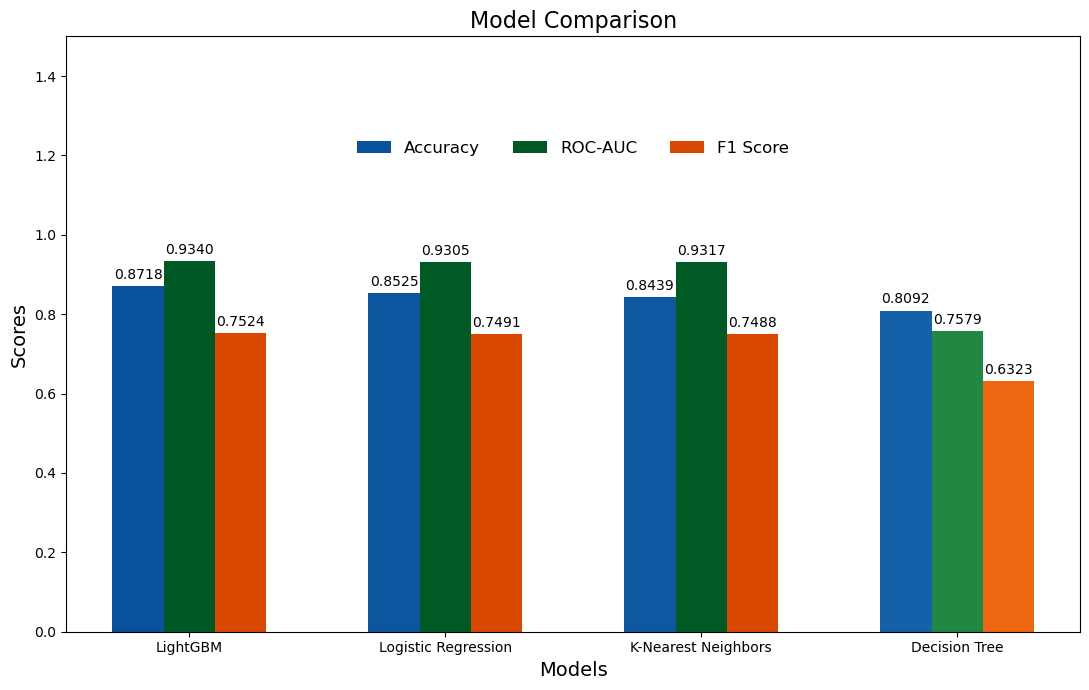

In [6]:
# plotting the comparison graph
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import matplotlib.cm as cm

# Collecting the metrics from each model
metrics = {
    'LightGBM': {
        'accuracy': accuracy_score(y_true_lr_vs_lgb, y_pred_lightgbm),
        'roc_auc': roc_auc_score(y_true_lr_vs_lgb, y_proba_lightgbm),
        'f1_score': f1_score(y_true_lr_vs_lgb, y_pred_lightgbm)
    },
    'Logistic Regression': {
        'accuracy': accuracy_score(y_true_lr_vs_lgb, y_pred_logreg),
        'roc_auc': roc_auc_score(y_true_lr_vs_lgb, y_proba_logreg),
        'f1_score': f1_score(y_true_lr_vs_lgb, y_pred_logreg)
    },
    'K-Nearest Neighbors': {
        'accuracy': accuracy_score(y_true_knn_vs_lgb, y_pred_knn),
        'roc_auc': roc_auc_score(y_true_knn_vs_lgb, y_proba_knn),
        'f1_score': f1_score(y_true_knn_vs_lgb, y_pred_knn)
    },
    'Decision Tree': {
        'accuracy': accuracy_score(y_true_tree_vs_lgb, y_pred_tree),
        'roc_auc': roc_auc_score(y_true_tree_vs_lgb, y_proba_tree),
        'f1_score': f1_score(y_true_tree_vs_lgb, y_pred_tree)
    }
}

# metrics into a plotting format
models = list(metrics.keys())
accuracy = [metrics[model]['accuracy'] for model in models]
roc_auc = [metrics[model]['roc_auc'] for model in models]
f1_score = [metrics[model]['f1_score'] for model in models]

# Creating gradient color maps with dark-to-light colors
def gradient_color(value, cmap_name):
    """Return a gradient color based on value and colormap name."""
    norm = plt.Normalize(vmin=0, vmax=1)
    cmap = cm.get_cmap(cmap_name)
    return cmap(norm(value))

# plotting graph
x = np.arange(len(models))
width = 0.2 

fig, ax = plt.subplots(figsize=(11, 7))

# distinct colors with dark-to-light gradients
rects1 = ax.bar(x - width, accuracy, width, label='Accuracy', color=[gradient_color(val, 'Blues') for val in accuracy])
rects2 = ax.bar(x, roc_auc, width, label='ROC-AUC', color=[gradient_color(val, 'Greens') for val in roc_auc])
rects3 = ax.bar(x + width, f1_score, width, label='F1 Score', color=[gradient_color(val, 'Oranges') for val in f1_score])

# labelling
ax.set_xlabel('Models', fontsize=14)
ax.set_ylabel('Scores', fontsize=14)
ax.set_title('Model Comparison', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.5)

# legends position inside the plot
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 0.85), ncol=3, fontsize=12, frameon=False) 

# data values
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()


In [7]:
# comparing our model output with the actual train labels
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Loading LightGBM pipeline
pipeline = joblib.load('LightGBM_pipeline.pkl')

# Loading sample data to test
new_data = pd.read_csv('train_data.csv')

# selecting 10 random rows
new_data = new_data.sample(n=10, random_state=27)

# Dropping the customer_ID column 
if 'customer_ID' in new_data.columns:
    customer_ids = new_data['customer_ID']
    new_data = new_data.drop(columns=['customer_ID'])
else:
    customer_ids = None

# Converting the date column to numerical feature
if 'S_2' in new_data.columns:
    new_data['S_2'] = pd.to_datetime(new_data['S_2'])
    reference_date = pd.to_datetime('1970-01-01')
    new_data['S_2'] = (new_data['S_2'] - reference_date).dt.days

# Predicting using lightGBM model
predictions = pipeline.predict(new_data)

# store output to dataframe
if customer_ids is not None:
    prediction_df = pd.DataFrame({
        'customer_ID': customer_ids,
        'prediction': predictions
    })
else:
    prediction_df = pd.DataFrame({
        'prediction': predictions
    })

# Saving the predictions into CSV file
prediction_df.to_csv('comparePredictions.csv', index=False)

# Loading the train labels
train_labels = pd.read_csv('train_labels.csv')

# Merging output and actual labels
comparison_df = pd.merge(prediction_df, train_labels, on='customer_ID')

# Compare the predicted values with the actual values
comparison_df['match'] = comparison_df['prediction'] == comparison_df['target']

print("\nComparison of Predictions and Actual Labels:")
comparison_df

/opt/conda/lib/python3.10/site-packages/sklearn/impute/_base.py:558: UserWarning: Skipping features without any observed values: ['S_2']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(



Comparison of Predictions and Actual Labels:


,customer_ID,prediction,target,match
0,13812c6d1b90e6bf54059f729bf2fb117cfebed815f65a...,0,0,True
1,0f5a6f1813f29f2b1c5ee660a76327a073d837c59dd95b...,0,0,True
2,1b28db178800dd576f08840bfa308bf8e529cba01df355...,0,0,True
3,25dea14016a13ef94b5927d681ae9af8586ad9e0a21f6c...,0,0,True
4,0a74a9ff5f6e6954cdb8627ebfd88a309497395285ce87...,1,1,True
5,24b5c1b21c525820171fa05216db02738625c6e8a4fa36...,0,0,True
6,2959fb5f45d96b0e73b0882cc71e0600aa2da95d69ae46...,1,1,True
7,2895bd1f9e288c2ffeff67e72237f50457d3db80a51d57...,0,0,True
8,2b5a59b8c35374bb78d311da6f26f122bbc24c12696005...,0,0,True
9,2ade4fa856086581198b412c42f07381f34f21a5935004...,1,0,False
